# Evaluate

In this notebook we evaluate the accuracy of the predicted alignments.

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
import os.path
import pandas as pd
import pickle

In [3]:
ANNOTATIONS_ROOT = Path('../Chopin_Mazurkas/annotations_beat')
query_list = Path('cfg_files/query.test.list')

### Evaluate hypothesis directory

First evaluate a single hypothesis directory.

In [4]:
def eval_dir(hypdir, querylist, hop_sec, savefile = None):
    
    allErrs = {}
    cnt = 0
    print(f'Processing {hypdir} ', end='')
    with open(querylist, 'r') as f:
        for line in f:
            parts = line.strip().split()
            assert len(parts) == 2
            basename = os.path.basename(parts[0]) + '__' + os.path.basename(parts[1])
            hypfile = hypdir + '/' + basename + '.pkl'
            if not os.path.exists(hypfile):
                print("X", end='')
                continue
            allErrs[basename] = eval_file(hypfile, hop_sec)
            cnt += 1
            if cnt % 500 == 0:
                print(".", end='')
    print(' done')
    if savefile:
        pickle.dump(allErrs, open(savefile, 'wb'))
        
    return allErrs

def eval_file(hypfile, hop_sec):
    parts = os.path.basename(hypfile).split('__')
    assert len(parts) == 2
    piece = extractPieceName(parts[0])
    annotfile1 = (ANNOTATIONS_ROOT / piece / parts[0]).with_suffix('.beat')
    annotfile2 = (ANNOTATIONS_ROOT / piece / parts[1]).with_suffix('.beat')
    gt1 = getTimestamps(annotfile1)
    gt2 = getTimestamps(annotfile2)
    hypalign = loadAlignment(hypfile) # warping path in frames
    if hypalign is None:
        err = [] # no valid path
    else:
        pred2 = np.interp(gt1, hypalign[0,:]*hop_sec, hypalign[1,:]*hop_sec)
        err = pred2 - gt2
    return err


def extractPieceName(fullpath):
    basename = os.path.basename(fullpath) # e.g. Chopin_Op068No3_Sztompka-1959_pid9170b-21
    parts = basename.split('_')
    piece = '_'.join(parts[0:2]) # e.g. Chopin_Op068No3
    return piece



def getTimestamps(annotfile):
    df = pd.read_csv(annotfile, header=None, sep='\s+', skiprows=3)
    return np.array(df[0])


def loadAlignment(hypfile):
    with open(hypfile, 'rb') as f:
        d = pickle.load(f)
    return d

Evaluate a single hypothesis directory.

In [5]:
hypdir = 'experiments_test/dtw_clean'
savefile = 'evaluations_test/dtw_clean.pkl'
hop_sec = 512 * 1 / 22050
allErrs = eval_dir(hypdir, query_list, hop_sec, savefile)

Processing experiments_test/dtw_clean ............... done


In [12]:
hypdir = 'experiments_test/dsdtw_clean'
savefile = 'evaluations_test/dsdtw_clean.pkl'
hop_sec = 512 * 1 / 22050
allErrs = eval_dir(hypdir, query_list, hop_sec, savefile)

Processing experiments_test/dsdtw_clean XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX

Evaluate all hypothesis directories.

In [13]:
def eval_all_dirs(rootdir, querylist, hop_sec, outdir):
    if not os.path.exists(outdir):
        os.mkdir(outdir)
    for hypdir in glob.glob(f'{rootdir}/ssdtw_*'):
        savefile = outdir + '/' + os.path.basename(hypdir) + '.pkl'
        allErrs = eval_dir(hypdir, querylist, hop_sec, savefile = savefile)

In [14]:
EXPERIMENTS_ROOT = 'experiments_test'
hop_sec = 512 * 1 / 22050
outdir = 'evaluations_test'
eval_all_dirs(EXPERIMENTS_ROOT, query_list, hop_sec, outdir)

### Plot error vs tolerance

In [15]:
def calc_error_rates(errFile, maxTol):
    
    # read from file
    with open(errFile, 'rb') as f:
        allErrs = pickle.load(f)
    
    # collect all errors
    errsFlat = []
    for query in allErrs:
        errs = np.array(allErrs[query])
        errsFlat.append(errs)
    errsFlat = np.concatenate(errsFlat)
    
    # calculate error rates
    errRates = np.zeros(maxTol+1)
    for i in range(maxTol+1):
        errRates[i] = np.mean(np.abs(errsFlat) > i/1000)
    
    return errRates, errsFlat

In [16]:
def calc_error_rates_batch(indir, basenames, maxTol):
    errRates = np.zeros((len(basenames), maxTol+1))
    allErrVals = []
    print('Computing error rates ', end='')
    for i, basename in enumerate(basenames):
        errFile = indir + '/' + basename + '.pkl'
        errRates[i,:], errors = calc_error_rates(errFile, maxTol)
        allErrVals.append(errors)
        print('.', end='')
    print(' done')
    return errRates, allErrVals

In [17]:
def plot_multiple_roc(errRates, basenames):
    numSystems = errRates.shape[0]
    maxTol = errRates.shape[1] - 1
    for i in range(numSystems):
        plt.plot(np.arange(maxTol+1), errRates[i,:] * 100.0)
    plt.legend(basenames, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.xlabel('Error Tolerance (ms)')
    plt.ylabel('Error Rate (%)')
    plt.show()
    return

In [18]:
EVAL_ROOT_DIR = 'evaluations_test'
# toPlot = ['dtw_clean', 'segmental_2_clean', 'segmental_4_clean', 'segmental_8_clean', 'segmental_16_clean', 'segmental_32_clean', 'pardtw_2_clean', 'pardtw_4_clean', 'pardtw_8_clean', 'pardtw_16_clean', 'pardtw_32_clean']
toPlot = ['dtw_clean', 'dsdtw_clean']
maxTol = 1000 # in msec
errRates, errVals = calc_error_rates_batch(EVAL_ROOT_DIR, toPlot, maxTol)

Computing error rates .. done


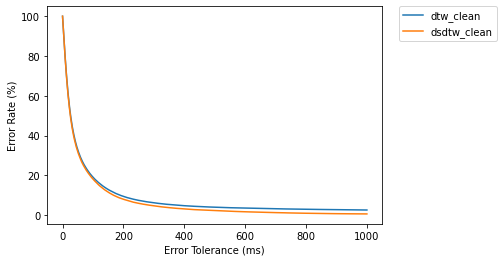

In [19]:
plot_multiple_roc(errRates, toPlot)

### Histogram of selected error rates

In [20]:
def plot_grouped_histogram1(errRates, basenames, tols):  
    # Histogram grouped by tolerance
    
    # first construct DataFrame
    data = []
    for i, system in enumerate(basenames):
        for tol in tols:
            data.append((system, tol, errRates[i,tol] * 100.0))
    df = pd.DataFrame(data, columns = ['System', 'Tolerance', 'Error'])
    
    # grouped barplot
    sns.barplot(x="Tolerance", y="Error", hue="System", data=df)
    plt.xlabel("Tolerance (ms)", size=14)
    plt.ylabel("Error Rate", size=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.show()
    
    return

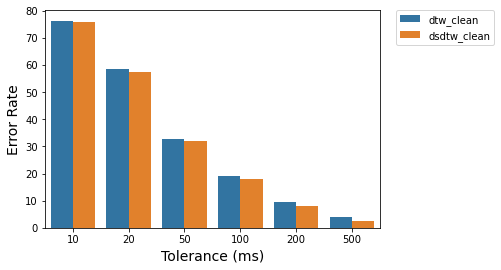

In [21]:
tols = [10, 20, 50, 100, 200, 500] # in msec
plot_grouped_histogram1(errRates, toPlot, tols)

### Final results plot for paper

This one is touched up to look nicer.

In [22]:
def plot_grouped_histogram1(errRates_bars, errRates_dots, basenames, tols, savefile = None):  
    # Histogram grouped by tolerance
    
    # first construct DataFrame
    data = []
    for i, system in enumerate(basenames):
        for tol in tols:
            data.append((system, tol, errRates[i,tol] * 100.0))
    df = pd.DataFrame(data, columns = ['System', 'Tolerance', 'Error'])
    
    # grouped barplot (DTW & WSDTW)
    sns.barplot(x="Tolerance", y="Error", hue="System", data=df)
    plt.xlabel("Tolerance (ms)", size=14)
    plt.ylabel("Error Rate (%)", size=14)
    #plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.legend(loc='upper right')
    
    # overlay dots for SSDTW results
    width_bar = .135
    x_coords = []
    y_coords = []
    for i, tol in enumerate(tols):
        for j in range(errRates_dots.shape[0]):
            x_coords.append(i+(-1.5+j)*width_bar)
            y_coords.append(errRates_dots[j,tol] * 100.0)
    plt.plot(x_coords, y_coords, 'ko', markersize=3)
    
    if savefile:
        plt.savefig(savefile, bbox_inches = 'tight')
    
    return

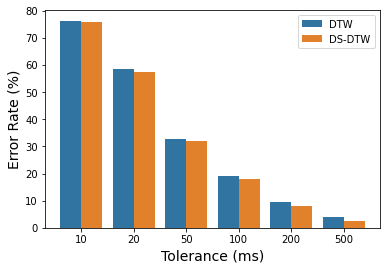

In [23]:
tols = [10, 20, 50, 100, 200, 500] # in msec
# display_names = ['DTW', 'SegDTW-2', 'SegDTW-4', 'SegDTW-8', 'SegDTW-16','SegDTW-32']
display_names = ['DTW', 'DS-DTW']
savefile = 'results.png'
plot_grouped_histogram1(errRates[0:6,:], errRates[6:,:], display_names, tols, savefile)

### Runtime Analysis

In [24]:
# dtw_runtimes, dtw_sizes = pickle.load(open('dtw_prof.pkl', 'rb'))
# wsdtw_runtimes, wsdtw_segments, wsdtw_sizes = pickle.load(open('wsdtw_prof.pkl', 'rb'))
# ssdtw_runtimes, ssdtw_segments, ssdtw_sizes = pickle.load(open('ssdtw_prof.pkl', 'rb'))

Numbers for runtime table

In [ ]:
# dtw_avgs = np.mean(np.sum(dtw_runtimes[::-1,:,:], axis=2), axis=1)

In [ ]:
# wsdtw_avgs = np.mean(np.sum(wsdtw_runtimes[:,::-1,:,:], axis=3), axis=2)

In [ ]:
# ssdtw_avgs = np.mean(np.sum(ssdtw_runtimes[:,::-1,:,:], axis=3), axis=2)

In [ ]:
# all_avgs = np.vstack((dtw_avgs.reshape((1,-1)), wsdtw_avgs, ssdtw_avgs))

In [ ]:
# first row: DTW
# next 5 rows: WSDTW with segments = 2, 4, 8, 16, 32
# next 5 rows: SSDTW with segments = 2, 4, 8, 16, 32
all_avgs

Breakdown of runtime by component

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3)

# DTW plot
ax = dtw_df.plot(kind="bar", stacked=True, colormap="rainbow", ax=axes[0])
ax.set_title("DTW")
ax.set_ylabel("% Total Runtime", size=13),
ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 10))
ax.xaxis.set_ticks_position('none') 
ax.set_xticklabels(labels=['1k','2k','5k','10k','20k','50k'], rotation=90, minor=False)
ax.get_legend().remove()

# DTW plot
ax = dsdtw_df.plot(kind="bar", stacked=True, colormap="rainbow", ax=axes[0])
ax.set_title("DS-DTW")
ax.set_ylabel("% Total Runtime", size=13),
ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 10))
ax.xaxis.set_ticks_position('none') 
ax.set_xticklabels(labels=['1k','2k','5k','10k','20k','50k'], rotation=90, minor=False)
ax.get_legend().remove()

# # Segmental DTW plot
# ax = wsdtw_df.plot(kind="bar", stacked=True, colormap="rainbow", ax=axes[1])
# ax.set_title("WSDTW-32")
# ax.set_xlabel("\nCost Matrix Size", size=13),
# ax.set_ylim(0, 100)
# ax.set_yticks([])
# ax.xaxis.set_ticks_position('none') 
# ax.set_xticklabels(labels=['1k','2k','5k','10k','20k','50k'], rotation=90, minor=False)
# ax.get_legend().remove()

# # Par DTW plot
# ax = ssdtw_df.plot(kind="bar", stacked=True, colormap="rainbow", ax=axes[2])
# ax.set_title("SSDTW-32")
# ax.set_ylim(0, 100)
# ax.set_yticks([])
# ax.xaxis.set_ticks_position('none') 
# ax.set_xticklabels(labels=['1k','2k','5k','10k','20k','50k'], rotation=90, minor=False)

# ax.legend(bbox_to_anchor=(1, 1))

plt.show()
#plt.savefig('runtime.png', bbox_inches = 'tight')

### Data Stats for paper

Collecting some stats on the audio data

In [ ]:
root_dir = 'Chopin_Mazurkas/wav_22050_mono'

In [ ]:
def printAudioStats(indir):
    durs = []
    for infile in glob.glob(f'{indir}/*.wav'):
        y, sr = lb.load(infile)
        durs.append(len(y)/sr)
    durs = np.array(durs)
    
    print(os.path.basename(indir))
    print('---------')
    print(f'Min: {np.min(durs)} s')
    print(f'Max: {np.max(durs)} s')
    print(f'Mean: {np.mean(durs)} s')
    print(f'Std: {np.std(durs)} s')

In [ ]:
for indir in glob.glob(f'{root_dir}/*'):
    printAudioStats(indir)